# Understanding the Raw NHANES Files

Before merging anything or training a model, I need to know exactly what is sitting in the source files. Government survey data is usually well documented, but it is not automatically model-ready and one file can contain thousands more people than another, and confusing notations like a code such as `99` can mean *don't know* rather than a real measurement, and the dental outcome is spread across 28 separate tooth columns.

This notebook audits the four NHANES components used in the project and answers four basic questions:

1. Does every file have one unique row per participant?
2. Can the files be joined safely through `SEQN`?
3. Are the cavity codes and candidate predictors present and coded as expected?
4. Where is information missing, and what will Notebook 02 need to do about it?

The goal here is inspection, not cleaning. Nothing is imputed, dropped, or exported in this notebook. The actual final dataset is made in the next notebook.


## The Data Source

The **National Health and Nutrition Examination Survey (NHANES)** combines questionnaires with physical examinations. These files come from the combined **2017–March 2020 pre-pandemic cycle**, which is why each filename begins with `P_`.

The project uses four components:

| File | NHANES component | Role in this project |
|---|---|---|
| `P_OHXDEN.xpt` | Oral Health Dentition Examination | Completed-exam status and the cavity target |
| `P_DEMO.xpt` | Demographics | Age, sex, race/ethnicity, and income-to-poverty ratio |
| `P_OHQ.xpt` | Oral Health Questionnaire | Time since last dental visit and self-rated teeth condition |
| `P_DIQ.xpt` | Diabetes Questionnaire | Diagnosed and borderline diabetes status |

Every participant has a unique identifier called **`SEQN`**. That identifier is the bridge between the files: if participant `109263` appears in the dental and demographic files, `SEQN` tells us those rows describe the same person.

Official documentation: [Dentition](https://wwwn.cdc.gov/Nchs/Nhanes/2017-2018/P_OHXDEN.htm) · [Demographics](https://wwwn.cdc.gov/Nchs/Nhanes/2017-2018/P_DEMO.htm) · [Oral-health questionnaire](https://wwwn.cdc.gov/Nchs/Nhanes/2017-2018/P_OHQ.htm) · [Diabetes](https://wwwn.cdc.gov/Nchs/Nhanes/2017-2018/P_DIQ.htm)


## Imports and Setup


In [ ]:
from pathlib import Path
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Plot styling
# Keeping the plots visually consistent with the CMOR repository.
sns.set_theme(style="whitegrid")
PURPLE = "#5d32ca"
GREEN = "#82b600"
BLUE = "#2196f3"
GRAY = "#6b7280"

# Locate the project root
# This path logic works whether Jupyter starts in the repository root
# or directly inside the notebooks folder.
current_directory = Path.cwd().resolve()
if (current_directory / "data" / "raw").exists():
    PROJECT_ROOT = current_directory
elif current_directory.name == "notebooks" and (current_directory.parent / "data" / "raw").exists():
    PROJECT_ROOT = current_directory.parent
else:
    raise FileNotFoundError(
        "Could not locate data/raw. Open this notebook from inside the project repository."
    )

RAW_DIR = PROJECT_ROOT / "data" / "raw"

# Map each NHANES component to its raw file path
SOURCE_FILES = {
    "Dental examination": RAW_DIR / "P_OHXDEN.xpt",
    "Demographics": RAW_DIR / "P_DEMO.xpt",
    "Oral-health questionnaire": RAW_DIR / "P_OHQ.xpt",
    "Diabetes questionnaire": RAW_DIR / "P_DIQ.xpt",
}

# Fail fast if any required raw file is missing
missing_files = [path.name for path in SOURCE_FILES.values() if not path.exists()]
if missing_files:
    raise FileNotFoundError(f"Missing required raw files: {missing_files}")

print("Project root located successfully.")
print("Raw data folder: data/raw")
print("All four required NHANES files were found.")


## Loading the Four Components

NHANES distributes these files in SAS transport format (`.xpt`). Pandas can read that format directly, so there is no need to manually open the files in Excel or convert them first. Keeping the original files untouched also gives the project a reproducible starting point.


In [4]:
# Load each raw XPT file into a pandas DataFrame
datasets = {
    name: pd.read_sas(path, format="xport", encoding="utf-8")
    for name, path in SOURCE_FILES.items()
}

# Give each DataFrame a short, readable name for use in later cells
dental = datasets["Dental examination"]
demo = datasets["Demographics"]
oral_health = datasets["Oral-health questionnaire"]
diabetes = datasets["Diabetes questionnaire"]

# Build a one-row-per-file summary of size and SEQN integrity
file_summary = pd.DataFrame(
    [
        {
            "Component": name,
            "Rows": len(frame),
            "Columns": frame.shape[1],
            "Unique SEQN": frame["SEQN"].nunique(),
            "Duplicate SEQN": frame["SEQN"].duplicated().sum(),
            "Missing SEQN": frame["SEQN"].isna().sum(),
        }
        for name, frame in datasets.items()
    ]
)

file_summary


,Component,Rows,Columns,Unique SEQN,Duplicate SEQN,Missing SEQN
0,Dental examination,13772,170,13772,0,0
1,Demographics,15560,29,15560,0,0
2,Oral-health questionnaire,14986,39,14986,0,0
3,Diabetes questionnaire,14986,28,14986,0,0


Each file has exactly one row per `SEQN`, with no missing or duplicated identifiers. That matters because a one-to-one merge should produce one row per person. If `SEQN` were duplicated, a merge could silently multiply rows and give some participants more influence than others.

The files are not the same size because not every NHANES participant completed every examination or questionnaire component. The dental file is the smallest and will define the starting population for this project.


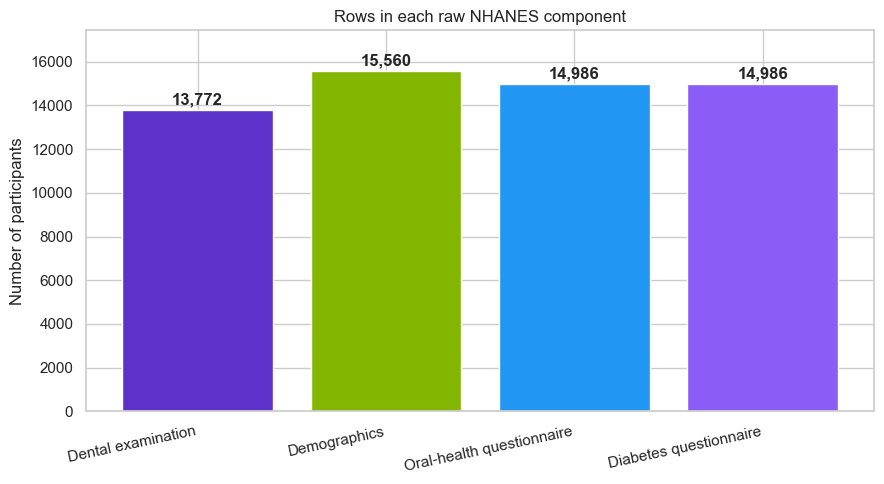

In [5]:
# Bar chart comparing participant counts across the four raw files
plt.figure(figsize=(9, 5))
bars = plt.bar(
    file_summary["Component"],
    file_summary["Rows"],
    color=[PURPLE, GREEN, BLUE, "#8b5cf6"],
)

for bar, value in zip(bars, file_summary["Rows"]):
    plt.text(bar.get_x() + bar.get_width() / 2, value + 120, f"{value:,}",
             ha="center", va="bottom", fontweight="bold")

plt.ylabel("Number of participants")
plt.title("Rows in each raw NHANES component")
plt.xticks(rotation=12, ha="right")
plt.ylim(0, file_summary["Rows"].max() * 1.12)
plt.tight_layout()
plt.show()


## Checking Whether the Participant IDs Overlap


In [6]:
# Build a set of SEQN values for each file, then find the IDs common to all four
id_sets = {name: set(frame["SEQN"]) for name, frame in datasets.items()}
shared_ids = set.intersection(*id_sets.values())
dental_ids = id_sets["Dental examination"]

# Summarize how many dental participants also appear in each other file
overlap_summary = pd.DataFrame(
    [
        {
            "Component": name,
            "Participants in file": len(ids),
            "Dental participants found": len(dental_ids & ids),
            "Dental participants missing": len(dental_ids - ids),
        }
        for name, ids in id_sets.items()
    ]
)

print(f"Participants shared by all four files: {len(shared_ids):,}")
overlap_summary


Participants shared by all four files: 13,772


,Component,Participants in file,Dental participants found,Dental participants missing
0,Dental examination,13772,13772,0
1,Demographics,15560,13772,0
2,Oral-health questionnaire,14986,13772,0
3,Diabetes questionnaire,14986,13772,0


All **13,772 people in the dental file also appear in the other three components**. This is the cleanest possible merge situation: the dental file is already a subset of the questionnaire and demographic files, so using it as the starting population will not unexpectedly lose participants during the join.


## Auditing the Dental Examination

`P_OHXDEN` is the most important source because it supplies the target. Before reading the tooth codes, I first check `OHDEXSTS`, the overall dentition-exam status. A participant should not be labeled cavity-free when their mouth was never examined.


In [9]:
# Map numeric exam-status codes to readable labels
exam_status_labels = {
    1.0: "Complete",
    2.0: "Partial",
    3.0: "Not done",
}

# Count participants in each status and express as a percentage of the raw file
exam_status = (
    dental["OHDEXSTS"]
    .map(exam_status_labels)
    .value_counts(dropna=False)
    .rename_axis("Dental exam status")
    .reset_index(name="Participants")
)

exam_status["Percent"] = exam_status["Participants"] / len(dental) * 100

# Hide the default row index so it isn't mistaken for the OHDEXSTS code itself
exam_status.style.hide(axis="index")


Dental exam status,Participants,Percent
Complete,13271,96.362184
Not done,494,3.586988
Partial,7,0.050828


Most participants completed the examination, but **501 did not have a complete exam**. Notebook 02 will keep only `OHDEXSTS = 1`. The seven partial exams are excluded along with the 494 exams that were not done, because an incomplete mouth could make a person look cavity-free simply because the affected tooth was not recorded.


### Finding the Tooth-Level Condition Fields


In [10]:
# Tooth-condition columns follow the pattern OHX##CTC.
# Teeth 01, 16, 17, and 32 are third molars and are not included in this component,
# leaving 28 condition fields.
tooth_condition_columns = [
    column for column in dental.columns
    if re.fullmatch(r"OHX\d{2}CTC", column)
]

# Restrict to participants whose dental exam was actually completed
complete_dental = dental.loc[dental["OHDEXSTS"].eq(1)].copy()

# Clean up the raw tooth codes (strip whitespace, normalize case)
tooth_codes = (
    complete_dental[tooth_condition_columns]
    .astype("string")
    .apply(lambda column: column.str.strip().str.upper())
)

# Flatten all 28 tooth columns to see which codes actually occur.
flat_codes = pd.Series(tooth_codes.to_numpy().ravel(), dtype="string")
code_counts = (
    flat_codes.replace("", pd.NA)
    .dropna()
    .value_counts()
    .rename_axis("Tooth condition code")
    .reset_index(name="Recorded teeth")
)

print(f"Tooth-condition columns found: {len(tooth_condition_columns)}")
print(f"First five columns: {tooth_condition_columns[:5]}")
code_counts


Tooth-condition columns found: 28
First five columns: ['OHX02CTC', 'OHX03CTC', 'OHX04CTC', 'OHX05CTC', 'OHX06CTC']


,Tooth condition code,Recorded teeth
0,S,199250
1,F,46984
2,D,39990
3,P,23639
4,U,23280
5,E,18540
6,Z,4889
7,A,3420
8,J,2785
9,M,2348


### Previewing the Cavity Definition

NHANES uses separate condition codes for primary and permanent teeth:

- `K` = untreated caries in a primary tooth
- `Z` = untreated caries in a permanent tooth

Therefore, the person-level target will be:

$$
\text{has\_cavity} =
\begin{cases}
1, & \text{if any of the 28 tooth fields contains K or Z} \\
0, & \text{otherwise}
\end{cases}
$$

Filled teeth do not count as untreated cavities. This cell only previews and checks the rule; Notebook 02 will formally construct and export the target.


In [11]:
# Flag participants with at least one untreated-caries code (K = primary tooth, Z = permanent tooth)
has_cavity_preview = tooth_codes.isin(["K", "Z"]).any(axis=1).astype(int)

# Summarize counts and percentages for this audit-only target
cavity_preview = (
    has_cavity_preview
    .value_counts()
    .sort_index()
    .rename(index={0: "No untreated cavity", 1: "At least one untreated cavity"})
    .rename_axis("Audit-only target")
    .reset_index(name="Participants")
)
cavity_preview["Percent"] = cavity_preview["Participants"] / len(complete_dental) * 100

cavity_preview


,Audit-only target,Participants,Percent
0,No untreated cavity,10836,81.651722
1,At least one untreated cavity,2435,18.348278


Among the 13,271 completed examinations, 2,435 participants have at least one `K` or `Z` code. That is about 18%, so the outcome is imbalanced but not extremely rare. Later notebooks will account for that imbalance with class-sensitive metrics and model weighting rather than relying on accuracy alone.


## Auditing the Demographic Predictors


The demographic file contributes four predictor groups:

| Variable | Meaning | Expected coding |
|---|---|---|
| `RIDAGEYR` | Age in years | 1–80, with 80 representing 80 or older in this analytic cohort |
| `RIAGENDR` | Sex | 1 = male, 2 = female |
| `RIDRETH3` | Race/ethnicity | Six documented categories used for one-hot encoding |
| `INDFMPIR` | Family income-to-poverty ratio | 0–5, with 5 representing 5 or greater |

Race and sex are recorded here as NHANES categories. Their inclusion does not imply that identity biologically causes cavities; they may capture differences in access, environment, and other unmeasured conditions. That distinction becomes important in the interpretation and subgroup notebooks.


In [13]:
# Restrict demographics to the completed-exam cohort
complete_ids = set(complete_dental["SEQN"])
demo_exam = demo.loc[demo["SEQN"].isin(complete_ids)].copy()

# Build a summary row per predictor: observed range/codes and count of invalid values
demographic_audit = pd.DataFrame(
    [
        {
            "Variable": "Age",
            "NHANES field": "RIDAGEYR",
            "Observed range/codes": f"{demo_exam['RIDAGEYR'].min():.0f}–{demo_exam['RIDAGEYR'].max():.0f}",
            "Unavailable or invalid": (~demo_exam["RIDAGEYR"].between(1, 80)).sum(),
        },
        {
            "Variable": "Sex",
            "NHANES field": "RIAGENDR",
            "Observed range/codes": sorted(demo_exam["RIAGENDR"].dropna().unique().astype(int).tolist()),
            "Unavailable or invalid": (~demo_exam["RIAGENDR"].isin([1, 2])).sum(),
        },
        {
            "Variable": "Race/ethnicity",
            "NHANES field": "RIDRETH3",
            "Observed range/codes": sorted(demo_exam["RIDRETH3"].dropna().unique().astype(int).tolist()),
            "Unavailable or invalid": (~demo_exam["RIDRETH3"].isin([1, 2, 3, 4, 6, 7])).sum(),
        },
        {
            "Variable": "Income-to-poverty ratio",
            "NHANES field": "INDFMPIR",
            "Observed range/codes": "0–5",
            "Unavailable or invalid": demo_exam["INDFMPIR"].isna().sum(),
        },
    ]
)

demographic_audit


,Variable,NHANES field,Observed range/codes,Unavailable or invalid
0,Age,RIDAGEYR,1–80,0
1,Sex,RIAGENDR,"[1, 2]",0
2,Race/ethnicity,RIDRETH3,"[1, 2, 3, 4, 6, 7]",0
3,Income-to-poverty ratio,INDFMPIR,0–5,1703


Age, sex, and race/ethnicity are complete in the dental-exam cohort. Income is different: **1,703 participants did not have an income-to-poverty ratio** before the later cohort exclusions. That is too many people to casually delete.

Notebook 02 will preserve those income values as missing and add a missingness flag. The modeling pipeline will calculate the median from each training fold and use that training-only value for imputation. Filling income here would let information from future validation or test participants influence preprocessing.

The demographic file also contains NHANES survey weights, strata, and cluster variables. Those are important if we want nationally representative prevalence estimates. They are not predictors in this project, and unweighted percentages will be described as percentages **within the analytic cohort**, not estimates for the entire United States.


## Auditing the Oral-Health Questionnaire


Two questionnaire fields are used because a person could reasonably answer them without a dental examination:

- `OHQ030`: how long it has been since the participant last visited a dentist
- `OHQ845`: how the participant rates the condition of their teeth and gums

The key issue is that NHANES uses numbers such as `9` and `99` for unknown responses. Those values must become missing—they are not real points on the ordinal scales.


In [14]:
# Restrict questionnaire responses to the completed-exam cohort
oral_exam = oral_health.loc[oral_health["SEQN"].isin(complete_ids)].copy()

# Check each field against its valid response range; anything else is invalid/unknown
oral_health_audit = pd.DataFrame(
    [
        {
            "Variable": "Time since last dental visit",
            "NHANES field": "OHQ030",
            "Valid values": "1–7",
            "Invalid/unknown codes": "99 or missing",
            "Unavailable or invalid": (~oral_exam["OHQ030"].isin(range(1, 8))).sum(),
        },
        {
            "Variable": "Self-rated teeth condition",
            "NHANES field": "OHQ845",
            "Valid values": "1–5",
            "Invalid/unknown codes": "9 or missing",
            "Unavailable or invalid": (~oral_exam["OHQ845"].isin(range(1, 6))).sum(),
        },
    ]
)

oral_health_audit


,Variable,NHANES field,Valid values,Invalid/unknown codes,Unavailable or invalid
0,Time since last dental visit,OHQ030,1–7,99 or missing,39
1,Self-rated teeth condition,OHQ845,1–5,9 or missing,12


Only 39 dental-visit responses and 12 teeth-condition responses are unavailable or invalid. These are tiny fractions of the cohort, so removing the affected rows is simpler and more transparent than estimating what those participants would have answered.

Self-rated teeth condition is also a **proximal predictor**: someone may rate their teeth poorly because they already feel or see a problem. It is still appropriate for a questionnaire-based risk model, but Notebook 06 will compare performance with and without it so the project does not hide how much the model depends on that awareness.


## Auditing Diabetes Status


In [15]:
# Restrict diabetes responses to the completed-exam cohort
diabetes_exam = diabetes.loc[diabetes["SEQN"].isin(complete_ids)].copy()

# Map diabetes codes to labels
diabetes_labels = {
    1.0: "Yes",
    2.0: "No",
    3.0: "Borderline",
    7.0: "Refused",
    9.0: "Don't know",
}

# Count responses in each category
diabetes_counts = (
    diabetes_exam["DIQ010"]
    .map(diabetes_labels)
    .fillna("Missing")
    .value_counts()
    .rename_axis("DIQ010 response")
    .reset_index(name="Participants")
)

diabetes_counts


,DIQ010 response,Participants
0,No,11738
1,Yes,1270
2,Borderline,255
3,Don't know,8


Eight participants answered *don't know*. The final model will represent `Yes` and `Borderline` with separate binary columns, leaving `No` as the reference group. The eight unknown responses will be removed rather than silently treated as no diabetes.


## Missingness After Aligning the Candidate Predictors


In [16]:
# Merge only the fields needed for the audit. validate="one_to_one" forces
# pandas to raise an error if any source unexpectedly contains duplicate IDs.
audit_cohort = (
    complete_dental[["SEQN"]]
    .merge(
        demo[["SEQN", "RIDAGEYR", "RIAGENDR", "RIDRETH3", "INDFMPIR"]],
        on="SEQN", how="left", validate="one_to_one"
    )
    .merge(
        oral_health[["SEQN", "OHQ030", "OHQ845"]],
        on="SEQN", how="left", validate="one_to_one"
    )
    .merge(
        diabetes[["SEQN", "DIQ010"]],
        on="SEQN", how="left", validate="one_to_one"
    )
)

# Tally unavailable/invalid values per predictor along with the planned handling rule
missingness_table = pd.DataFrame(
    [
        ("Age", "RIDAGEYR", (~audit_cohort["RIDAGEYR"].between(1, 80)).sum(), "Keep"),
        ("Sex", "RIAGENDR", (~audit_cohort["RIAGENDR"].isin([1, 2])).sum(), "Keep"),
        ("Race/ethnicity", "RIDRETH3", (~audit_cohort["RIDRETH3"].isin([1, 2, 3, 4, 6, 7])).sum(), "Keep"),
        ("Income-to-poverty ratio", "INDFMPIR", audit_cohort["INDFMPIR"].isna().sum(), "Keep missing + add flag"),
        ("Last dental visit", "OHQ030", (~audit_cohort["OHQ030"].isin(range(1, 8))).sum(), "Drop affected rows"),
        ("Self-rated teeth", "OHQ845", (~audit_cohort["OHQ845"].isin(range(1, 6))).sum(), "Drop affected rows"),
        ("Diabetes status", "DIQ010", (~audit_cohort["DIQ010"].isin([1, 2, 3])).sum(), "Drop affected rows"),
    ],
    columns=["Project variable", "NHANES field", "Unavailable or invalid", "Planned handling"],
)

# Convert raw counts to a percentage of the completed-exam cohort
missingness_table["Percent of completed exams"] = (
    missingness_table["Unavailable or invalid"] / len(audit_cohort) * 100
)

missingness_table


,Project variable,NHANES field,Unavailable or invalid,Planned handling,Percent of completed exams
0,Age,RIDAGEYR,0,Keep,0.000000
1,Sex,RIAGENDR,0,Keep,0.000000
2,Race/ethnicity,RIDRETH3,0,Keep,0.000000
3,Income-to-poverty ratio,INDFMPIR,1703,Keep missing + add flag,12.832492
4,Last dental visit,OHQ030,39,Drop affected rows,0.293874
5,Self-rated teeth,OHQ845,12,Drop affected rows,0.090423
6,Diabetes status,DIQ010,8,Drop affected rows,0.060282


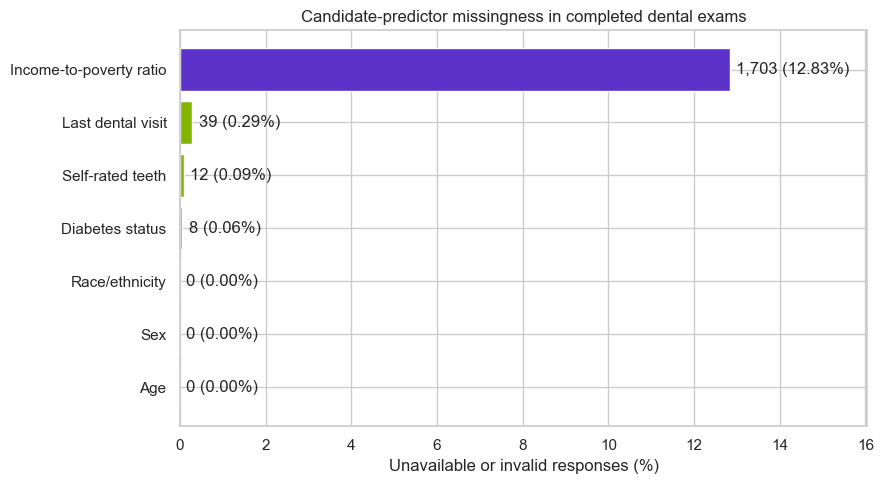

In [17]:
# Horizontal bar chart of missingness percentage per predictor, sorted ascending
plot_data = missingness_table.sort_values("Percent of completed exams")

plt.figure(figsize=(9, 5))
bars = plt.barh(
    plot_data["Project variable"],
    plot_data["Percent of completed exams"],
    color=[GREEN if value < 1 else PURPLE for value in plot_data["Percent of completed exams"]],
)

for bar, count, percent in zip(
    bars,
    plot_data["Unavailable or invalid"],
    plot_data["Percent of completed exams"],
):
    plt.text(
        bar.get_width() + 0.15,
        bar.get_y() + bar.get_height() / 2,
        f"{count:,} ({percent:.2f}%)",
        va="center",
    )

plt.xlabel("Unavailable or invalid responses (%)")
plt.title("Candidate-predictor missingness in completed dental exams")
plt.xlim(0, plot_data["Percent of completed exams"].max() * 1.25)
plt.tight_layout()
plt.show()


This is a clean dataset overall. Six predictor groups are complete or missing in less than one-third of one percent of participants. Income is the only variable with substantial missingness, at about 13%.

A clean dataset does not necessarily mean one with no blank cells. It means the missingness has been identified, interpreted, and assigned a defensible handling rule before model training begins.


## Brief Note on the Dietary File

The `P_DBQ` dietary questionnaire was considered because sugar intake is biologically relevant to dental caries. It is not included in the main model because the most useful candidate questions were incomplete, age-specific, or indirect proxies that would either shrink the cohort substantially or be difficult to interpret consistently.

Leaving diet out is a limitation, not a claim that diet does not matter. A future version could add detailed dietary-recall components as a separate extension, but the first model stays focused on variables that are clearly defined across nearly the entire dental-exam cohort.


## Final Sanity Checks


In [18]:
# Reattach the audit-only cavity label so we can preview the expected final cohort.
target_preview = complete_dental[["SEQN"]].copy()
target_preview["has_cavity"] = has_cavity_preview.to_numpy()

audit_with_target = audit_cohort.merge(
    target_preview, on="SEQN", how="left", validate="one_to_one"
)

# Notebook 02 will remove only the small-missingness questionnaire rows.
eligible_for_final_cohort = (
    audit_with_target["OHQ030"].isin(range(1, 8))
    & audit_with_target["OHQ845"].isin(range(1, 6))
    & audit_with_target["DIQ010"].isin([1, 2, 3])
)

# Apply the exclusion rule to project the final cohort size
projected_cohort = audit_with_target.loc[eligible_for_final_cohort].copy()

# Assemble a summary table of cohort sizes and target counts at each stage
final_audit_summary = pd.DataFrame(
    {
        "Check": [
            "Raw dental participants",
            "Completed dental examinations",
            "Projected final cohort",
            "Projected cavity cases",
            "Projected non-cavity cases",
            "Missing income retained in final cohort",
            "Duplicate SEQN in final cohort",
        ],
        "Result": [
            len(dental),
            len(complete_dental),
            len(projected_cohort),
            int(projected_cohort["has_cavity"].sum()),
            int((projected_cohort["has_cavity"] == 0).sum()),
            int(projected_cohort["INDFMPIR"].isna().sum()),
            int(projected_cohort["SEQN"].duplicated().sum()),
        ],
    }
)

# These assertions turn the audit into an active reliability check. If a source
# file changes or a rule is applied incorrectly later, the notebook should fail loudly.
assert len(tooth_condition_columns) == 28
assert file_summary["Duplicate SEQN"].sum() == 0
assert len(shared_ids) == 13_772
assert len(complete_dental) == 13_271
assert len(projected_cohort) == 13_215
assert projected_cohort["has_cavity"].sum() == 2_420
assert projected_cohort["INDFMPIR"].isna().sum() == 1_684
assert projected_cohort["SEQN"].duplicated().sum() == 0

print("All audit checks passed.")
final_audit_summary


All audit checks passed.


,Check,Result
0,Raw dental participants,13772
1,Completed dental examinations,13271
2,Projected final cohort,13215
3,Projected cavity cases,2420
4,Projected non-cavity cases,10795
5,Missing income retained in final cohort,1684
6,Duplicate SEQN in final cohort,0


## Conclusion

The four NHANES components are suitable for a reproducible modeling pipeline. Every file has one row per participant, every dental participant appears in the other three sources, the completed-exam requirement is clear, and the cavity definition can be built consistently from 28 tooth-level fields.

The audit also gives Notebook 02 an exact plan:

1. Start with 13,772 dental records.
2. Keep the 13,271 completed examinations.
3. Define `has_cavity = 1` when any tooth contains `K` or `Z`.
4. Merge demographics, oral-health responses, and diabetes status through `SEQN`.
5. Remove the 56 participants with unavailable dental-visit, teeth-condition, or diabetes responses.
6. Keep the remaining 13,215 participants, including 1,684 whose income is missing.
7. Preserve missing income for training-fold imputation rather than filling it before the split.

The most important result is not that the files are perfect. It is that every imperfection is now visible and has a documented plan. The next notebook will turn these raw components into the single modeling table used by the rest of the project.
